In [1]:
import os
import numpy as np
import pynbody
import pickle

from BWSB_config import db_connection, sys_path, pickle_file, results_output_directory
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['PYTHONPATH'] = sys_path
import tangos
sims = tangos.all_simulations()

bw_sims = sims[2:4]
sb_sims = sims[0:2]
pickle_file = 'ellipse_data_v_stars_BW-SB.pickle'
with open(pickle_file, "rb") as f:
    ellipse_dict = pickle.load(f)

In [ ]:
image1 = sims[0].timesteps[0].halos[5]['halo_images_v'][0]
image2 = sims[0].timesteps[0].halos[8]['halo_images_v'][0]

In [3]:
bw_sims

[<Simulation("storm.cosmo25cmb.4096g5HbwK1BH")>,
 <Simulation("elektra.cosmo25cmb.4096g5HbwK1BH")>]

In [4]:
print(len(image1),len(image2))

1000 1000


In [5]:
simpath = '/home/bk639/data/BW-SB_comparision/'
import pynbody
for sim in sims:
    s = pynbody.load(simpath+sim.timesteps[0].path)
    s.physical_units()
    halos = s.halos(halo_numbers='v1')
    print(halos[1].properties.keys())

dict_keys(['omegaM0', 'omegaL0', 'h', 'boxsize', 'a', 'time', 'halo_number', 'ID', 'hostHalo', 'numSubStruct', 'Mhalo', 'npart', 'Xc', 'Yc', 'Zc', 'VXc', 'VYc', 'VZc', 'Rhalo', 'Rmax', 'r2', 'mbp_offset', 'com_offset', 'Vmax', 'v_esc', 'sigV', 'lambda', 'lambdaE', 'Lx', 'Ly', 'Lz', 'b', 'c', 'Eax', 'Eay', 'Eaz', 'Ebx', 'Eby', 'Ebz', 'Ecx', 'Ecy', 'Ecz', 'ovdens', 'nbins', 'fMhires', 'Ekin', 'Epot', 'SurfP', 'Phi0', 'cNFW', 'n_gas', 'M_gas', 'lambda_gas', 'lambdaE_gas', 'Lx_gas', 'Ly_gas', 'Lz_gas', 'b_gas', 'c_gas', 'Eax_gas', 'Eay_gas', 'Eaz_gas', 'Ebx_gas', 'Eby_gas', 'Ebz_gas', 'Ecx_gas', 'Ecy_gas', 'Ecz_gas', 'Ekin_gas', 'Epot_gas', 'n_star', 'M_star', 'lambda_star', 'lambdaE_star', 'Lx_star', 'Ly_star', 'Lz_star', 'b_star', 'c_star', 'Eax_star', 'Eay_star', 'Eaz_star', 'Ebx_star', 'Eby_star', 'Ebz_star', 'Ecx_star', 'Ecy_star', 'Ecz_star', 'Ekin_star', 'Epot_star', 'children', 'parent'])


KeyboardInterrupt: 

In [ ]:
q_sideon =[]
orientations_strings = []
x = 90
y_l = np.arange(0, 180, 30)
for y in y_l:
    orientation = f'x{x:03d}y{y:03d}'
    orientations_strings.append(orientation)
for sim in ellipse_dict:
    for halo in ellipse_dict[sim]:
        q_sideon_candidates = []
        for orientation in orientations_strings:
            q_sideon_candidates.append(1-ellipse_dict[sim][halo][orientation][0])
        q_sideon.append(np.nanmin(q_sideon_candidates))

print(q_sideon)

In [ ]:
ellipse_dict[sim][halo].keys()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from collections import Counter
import tangos.relation_finding.one_hop


# ── tuneable thresholds ────────────────────────────────────────────────────────
NDM_RATIO_THRESHOLD   = 0.8   # |NDM_bw / NDM_sb - 1| must be < this
NSTAR_RATIO_THRESHOLD = 0.1   # same for stellar particles
# ──────────────────────────────────────────────────────────────────────────────


# ── halo properties to collect ────────────────────────────────────────────────
# Each entry: (output_key, calculate_expression).
#
# `halo.calculate(expr)` is invoked for every accepted halo. If the result is
# callable (e.g. a profile object), it is evaluated at the pair's radius
# r = 2 * reff. The value is finally coerced to float.
#
# To add a new column to the returned dict, append a tuple here, e.g.
#     ('mvir',  'Mvir()'),
#     ('vmax',  'Vmax()'),
# and it will be collected for every accepted halo automatically.
HALO_PROPERTIES = [
    ('ba_s', 'ba_s_smoothed()'),
    ('ca_s', 'ca_s_smoothed()'),
]
# ──────────────────────────────────────────────────────────────────────────────

def extract_single_value(value):
    """Extract scalar value from potentially nested data structures"""
    if isinstance(value, list):
        return value[0]
    return float(value)


def _print_match_info(info):
    status = "✓ PASS" if info["passed"] else "✗ FAIL"
    method = info.get("match_method") or "—"

    w_sb = f"{info['weight_sb']:.2f}" if info["weight_sb"] is not None else "—"
    w_bw = f"{info['weight_bw']:.2f}" if info["weight_bw"] is not None else "—"

    ndm_r   = f"{info['ndm_ratio']:.2f}"   if info["ndm_ratio"]   is not None else "—"
    nstar_r = f"{info['nstar_ratio']:.2f}" if info["nstar_ratio"] is not None else "—"

    method_tag = f"[{method}]"
    print(
        f"  {status} {method_tag:<22s}  {info['sb_halo']:<30s}"
        f"  →  {str(info['bw_halo']):<30s}"
        f"  w↑={w_sb}  w↓={w_bw}  ndm={ndm_r}  nstar={nstar_r}"
    )
    if not info["passed"]:
        print(f"          reason: {info['fail_reason']}")


def _print_summary(diagnostics):
    total    = len(diagnostics)
    passed   = [d for d in diagnostics if d["passed"]]
    failed   = [d for d in diagnostics if not d["passed"]]

    full_bidi = sum(1 for d in passed if d["match_method"] == "bidirectional")
    fallback  = sum(1 for d in passed if d["match_method"] == "fallback_particles")

    reasons = Counter(
        d["fail_reason"].split(":")[0].split("(")[0].strip()
        for d in failed if d["fail_reason"]
    )

    print(f"\n{'═'*70}")
    print(f"  Passed: {len(passed)}/{total}  "
          f"({full_bidi} bidirectional, {fallback} particle-count fallback)")
    if reasons:
        print("  Failure breakdown:")
        for reason, count in reasons.most_common():
            print(f"    • {reason}: {count}")
    print(f"{'═'*70}\n")


def _particle_ratio(a, b):
    """Symmetric ratio: 1.0 = perfect match, lower = more different."""
    if a == 0 and b == 0:
        return 1.0
    if a == 0 or b == 0:
        return 0.0
    return min(a, b) / max(a, b)


def _match_halo_pair(sb_halo, bw_sim, sb_sim,
                     weight_threshold=0.6, min_stars=6000):
    info = {
        "sb_halo":           str(sb_halo),
        "bw_halo":           None,
        "bw_halo_candidate": None,
        "weight_sb":         None,
        "weight_bw":         None,
        "ndm_ratio":         None,
        "nstar_ratio":       None,
        "match_method":      None,
        "passed":            False,
        "marginal":          False,
        "fail_reason":       None,
    }
    # ── 1. Star-count gate on SB halo ─────────────────────────────────────────
    sb_nstar = sb_halo.calculate("NStar()")
    if sb_nstar < min_stars:
        info["fail_reason"] = f"SB too few stars ({sb_nstar} < {min_stars})"
        return None, info

    # ── 2. Forward hop: SB → BW ───────────────────────────────────────────────
    fwd = tangos.relation_finding.one_hop.HopStrategy(sb_halo, bw_sim)
    bw_halo = fwd.first()

    info["bw_halo_candidate"] = bw_halo

    if bw_halo is None:
        info["fail_reason"] = "No forward match found (SB → BW)"
        return None, info

    fwd_weights = fwd.weights()
    weight_sb   = fwd_weights[0] if fwd_weights else None
    info["bw_halo"]   = str(bw_halo)
    info["weight_sb"] = weight_sb

    bw_nstar = bw_halo.calculate("NStar()")
    if bw_nstar < min_stars:
        info["fail_reason"] = f"BW too few stars ({bw_nstar} < {min_stars})"
        return None, info

    # ── 3. Reverse hop: BW → SB ───────────────────────────────────────────────
    rev           = tangos.relation_finding.one_hop.HopStrategy(bw_halo, sb_sim)
    sb_halo_back  = rev.first()
    rev_weights   = rev.weights()
    weight_bw     = rev_weights[0] if rev_weights else None
    info["weight_bw"] = weight_bw

    # ── 4. Decide: full bidirectional, or particle-count fallback? ─────────────
    reverse_link_missing = (sb_halo_back is None or not rev_weights)

    if reverse_link_missing:
        print(f"    [FALLBACK] No reverse link for {bw_halo} → {sb_sim.basename}. "
              f"Checking particle counts.")
        info["match_method"] = "fallback_particles"

        sb_ndm = sb_halo.calculate("NDM()")
        bw_ndm = bw_halo.calculate("NDM()")
        ndm_ratio   = _particle_ratio(sb_ndm, bw_ndm)
        nstar_ratio = _particle_ratio(sb_nstar, bw_nstar)
        info["ndm_ratio"]   = ndm_ratio
        info["nstar_ratio"] = nstar_ratio

        if ndm_ratio < NDM_RATIO_THRESHOLD:
            info["fail_reason"] = (
                f"Fallback: NDM ratio too low "
                f"(SB={sb_ndm}, BW={bw_ndm}, ratio={ndm_ratio:.2f} < {NDM_RATIO_THRESHOLD})"
            )
            return None, info

        if nstar_ratio < NSTAR_RATIO_THRESHOLD:
            info["fail_reason"] = (
                f"Fallback: NStar ratio too low "
                f"(SB={sb_nstar}, BW={bw_nstar}, ratio={nstar_ratio:.2f} < {NSTAR_RATIO_THRESHOLD})"
            )
            return None, info

        if weight_sb is not None and weight_sb < weight_threshold:
            info["fail_reason"] = (
                f"Fallback: forward weight too low "
                f"({weight_sb:.2f} < {weight_threshold}) — not trusting match"
            )
            return None, info

        info["passed"] = True
        return bw_halo, info

    # ── NORMAL (bidirectional) PATH ────────────────────────────────────────────
    info["match_method"] = "bidirectional"

    if sb_halo_back is not sb_halo:
        info["fail_reason"] = (
            f"Reverse match points elsewhere "
            f"({sb_halo_back} ≠ {sb_halo}) — possible duplicate or split"
        )
        return None, info

    if weight_sb is not None and weight_sb < weight_threshold:
        info["fail_reason"] = f"Forward weight too low ({weight_sb:.2f} < {weight_threshold})"
        return None, info

    if weight_bw is not None and weight_bw < weight_threshold:
        info["fail_reason"] = f"Reverse weight too low ({weight_bw:.2f} < {weight_threshold})"
        return None, info

    info["passed"] = True
    return bw_halo, info


def detect_swapped_pairs(diagnostics):
    """
    Flag cases where halo A→X fails with high w↑/low w↓
    and halo B→Y fails with low w↑/high w↓,
    suggesting the halo finder splits the same mass differently.
    """
    high_fwd = [d for d in diagnostics
                if not d["passed"]
                and d["weight_sb"] is not None and d["weight_sb"] > 0.8
                and d["weight_bw"] is not None and d["weight_bw"] < 0.5]

    high_rev = [d for d in diagnostics
                if not d["passed"]
                and d["weight_sb"] is not None and d["weight_sb"] < 0.5
                and d["weight_bw"] is not None and d["weight_bw"] > 0.8]

    if high_fwd and high_rev:
        print("\n  ⚠  Possible halo boundary swap detected:")
        print("     These pairs may be the same mass split differently by the halo finder:")
        for a in high_fwd:
            print(f"     {a['sb_halo']} → {a['bw_halo']}  (w↑={a['weight_sb']:.2f}, w↓={a['weight_bw']:.2f})")
        for b in high_rev:
            print(f"     {b['sb_halo']} → {b['bw_halo']}  (w↑={b['weight_sb']:.2f}, w↓={b['weight_bw']:.2f})")


# ── per-halo data extraction & row commit ────────────────────────────────────

def _extract_halo_data(halo, sim_basename, ellipse_dict, sideon_o, r=None):
    """
    Extract all configured properties from `halo`.

    Parameters
    ----------
    halo         : tangos halo
    sim_basename : str — used to look up ellipse_dict entries
    ellipse_dict : nested dict of projected-shape data
    sideon_o     : list of side-on view keys for ca_s_v
    r            : float or None — evaluation radius for function-valued
                   properties. If None, uses 2 * (halo's own reff).

    Returns
    -------
    (data, err)
        data : dict of {column_name: value} on success, or None on hard failure.
        err  : str describing the failure (None on success).

    Hard failures: missing reff, or any HALO_PROPERTIES expression raising.
    Soft failures (projected shapes from ellipse_dict): set to NaN.
    """
    out = {}

    try:
        reff = extract_single_value(halo['image_reffs_v'][0])
    except Exception as e:
        return None, f"missing reff ({e})"
    if r is None:
        r = 2 * reff

    # halo.calculate properties — all hard-required
    for key, expr in HALO_PROPERTIES:
        try:
            val = halo.calculate(expr)
            if callable(val):
                val = val(r)
            out[key] = float(val)
        except Exception as e:
            return None, f"failed '{expr}' ({e})"

    # projected-shape lookup — soft
    halo_ref = f'{sim_basename}/%/{halo.basename}'
    try:
        data = ellipse_dict[sim_basename][halo_ref]
        out['ba_s_v'] = data['x000y000'][1]
        out['ca_s_v'] = np.nanmin([data[s][1] for s in sideon_o])
    except Exception:
        out['ba_s_v'] = np.nan
        out['ca_s_v'] = np.nan

    return out, None


def _make_columns():
    """Pre-initialise the column collector so every key exists from the start."""
    cols = {}
    for key, _ in HALO_PROPERTIES:
        cols[key] = []
    cols['ba_s_v']        = []
    cols['ca_s_v']        = []
    cols['sims']          = []
    cols['feedback_type'] = []
    cols['halo_id']       = []
    cols['linked']        = []
    return cols


def _commit_halo(columns, data, sim_name, feedback, halo_id, linked):
    """Append one halo row (data + metadata) across every column."""
    for key, val in data.items():
        columns[key].append(val)
    columns['sims'].append(sim_name)
    columns['feedback_type'].append(feedback)
    columns['halo_id'].append(halo_id)
    columns['linked'].append(linked)


def _append_unlinked(info, sb_halo, sb_sim, bw_sim, sim_name,
                     ellipse_dict, sideon_o, columns, start_id):
    """Commit unlinked SB halo (always) and its BW candidate if present.
    Each side uses its own reff (no shared evaluation radius)."""
    sb_data, err = _extract_halo_data(
        sb_halo, sb_sim.basename, ellipse_dict, sideon_o,
    )
    if sb_data is None:
        print(f"    [UNLINKED] Could not get SB data for {sb_halo}: {err}")
    else:
        _commit_halo(columns, sb_data, sim_name, 'SB',
                     halo_id=start_id, linked=False)

    bw_candidate = info.get('bw_halo_candidate')
    if bw_candidate is not None:
        bw_data, err = _extract_halo_data(
            bw_candidate, bw_sim.basename, ellipse_dict, sideon_o,
        )
        if bw_data is None:
            print(f"    [UNLINKED] Could not get BW data for {bw_candidate}: {err}")
        else:
            _commit_halo(columns, bw_data, sim_name, 'BW',
                         halo_id=start_id - 1, linked=False)


# ── main entry point ─────────────────────────────────────────────────────────

def collect_shape_data(sb_sims, bw_sims, n_halos=10,
                       weight_threshold=0.6, min_stars=6000,
                       include_unlinked=False, verbose=True):

    bw_map = {sim.basename.split('.')[0]: sim for sim in bw_sims}

    columns          = _make_columns()
    pair_id          = 0
    unlinked_id      = -1
    matched_bw_halos = {}
    all_diagnostics  = []

    sideon_o = [f'x090y{i:03d}' for i in np.arange(0, 330, 30)]

    for sb_sim in sb_sims:
        sim_name = sb_sim.basename.split('.')[0]
        if sim_name not in bw_map:
            print(f"[SKIP] No BW counterpart for '{sim_name}'")
            continue

        bw_sim   = bw_map[sim_name]
        sb_halos = sb_sim.timesteps[0].halos

        print(f"\n{'─'*70}")
        print(f"  Sim: {sim_name}  (checking up to {n_halos} halos)")
        print(f"{'─'*70}")

        for sb_halo in sb_halos[:n_halos]:
            bw_halo, info = _match_halo_pair(
                sb_halo, bw_sim, sb_sim,
                weight_threshold=weight_threshold,
                min_stars=min_stars,
            )
            info["sim"] = sim_name
            all_diagnostics.append(info)

            # ── duplicate check ──────────────────────────────────────────────
            if bw_halo is not None and bw_halo in matched_bw_halos:
                prev_sb, prev_id = matched_bw_halos[bw_halo]
                info["passed"]      = False
                info["fail_reason"] = (
                    f"DUPLICATE: BW halo already claimed by "
                    f"{prev_sb} (pair_id={prev_id})"
                )
                bw_halo = None

            if verbose:
                _print_match_info(info)

            # ── failed match — optionally keep as unlinked ───────────────────
            if bw_halo is None:
                if include_unlinked:
                    _append_unlinked(
                        info, sb_halo, sb_sim, bw_sim, sim_name,
                        ellipse_dict, sideon_o, columns, unlinked_id,
                    )
                    unlinked_id -= 1 + (info["bw_halo_candidate"] is not None)
                continue

            # ── accepted pair: shared evaluation radius from BW reff ─────────
            try:
                bw_reff = extract_single_value(bw_halo['image_reffs_v'][0])
            except Exception:
                print(f"  [SKIP] missing reff for BW {bw_halo.path}  "
                      f"NStar={bw_halo.calculate('NStar()')}")
                continue
            r = 2 * bw_reff

            sb_data, err = _extract_halo_data(
                sb_halo, sb_sim.basename, ellipse_dict, sideon_o, r=r,
            )
            if sb_data is None:
                print(f"  [SKIP] SB {sb_halo.path}: {err}")
                continue

            bw_data, err = _extract_halo_data(
                bw_halo, bw_sim.basename, ellipse_dict, sideon_o, r=r,
            )
            if bw_data is None:
                print(f"  [SKIP] BW {bw_halo.path}: {err}")
                continue

            # all data in hand — commit both rows atomically
            matched_bw_halos[bw_halo] = (str(sb_halo), pair_id)
            _commit_halo(columns, sb_data, sim_name, 'SB', pair_id, True)
            _commit_halo(columns, bw_data, sim_name, 'BW', pair_id, True)
            pair_id += 1


        bw_halos = bw_sim.timesteps[0].halos
        for bw_halo in bw_halos[:n_halos]:
            if bw_halo in matched_bw_halos or not include_unlinked:
                continue

            bw_data, err = _extract_halo_data(
                bw_halo, bw_sim.basename, ellipse_dict, sideon_o,
            )
            if bw_data is None:
                print(f"    [UNLINKED-BW] {err} for {bw_halo}")
                continue

            _commit_halo(columns, bw_data, sim_name, 'BW', unlinked_id, False)
            unlinked_id -= 1

    _print_summary(all_diagnostics)
    detect_swapped_pairs(all_diagnostics)

    # ── lists → numpy arrays ─────────────────────────────────────────────────
    dtypes = {'halo_id': int, 'linked': bool,
              'sims': None, 'feedback_type': None}   # None = str (let numpy infer)
    result = {}
    for key, vals in columns.items():
        dt = dtypes.get(key, float)
        result[key] = np.array(vals, dtype=dt) if dt is not None else np.array(vals)
    return result

In [7]:
class ShapeColorPlotter:
    """
    Scatter + histogram plotter where:
        color  → feedback type  (SB = red, BW = blue)
        marker → simulation name (one shape per unique basename)

    Legend has exactly 4 handles:
        [SB color swatch] [BW color swatch] [sim-A shape] [sim-B shape]
    """

    FEEDBACK_COLORS = {'SB': '#D94F4F', 'BW': '#4878CF'}
    FEEDBACK_LABELS = {'SB': 'Superbubble (SB)', 'BW': 'Blastwave (BW)'}

    # Cycle of distinct markers assigned to unique sim names automatically
    MARKER_CYCLE = ['o', 's', '^', 'D', 'v', 'P', 'X', 'h']

    def __init__(self, data, sim_markers: dict = None):
        """
        Parameters
        ----------
        data        : dict from collect_shape_data()
        sim_markers : optional {sim_name: marker_string} override,
                      e.g. {'elektra': 'o', 'storm': 's'}
                      Auto-assigned from MARKER_CYCLE if None.
        """
        self.data = data

        unique_sims = np.unique(data['sims'])
        if sim_markers is None:
            sim_markers = {
                s: m for s, m in zip(unique_sims, self.MARKER_CYCLE)
            }
        self.sim_markers = sim_markers

        reff = data.get('reff_multi', 1)
        self.suptitle = rf'{reff}R$_{{\rm eff}}$' if reff != 1 else r'R$_{\rm eff}$'

        # font / size knobs
        self.point_size  = 90
        self.legend_fs   = 13
        self.axis_fs     = 17
        self.tick_fs     = 13
        self.bin_count   = 12

    # ── internal helpers ──────────────────────────────────────────────────────

    def _groups(self):
        """Yield (sim_name, feedback, boolean_mask) for every combo present."""
        for fb in np.unique(self.data['feedback_type']):
            for sim in np.unique(self.data['sims']):
                mask = (
                    (self.data['feedback_type'] == fb) &
                    (self.data['sims'] == sim)
                )
                if mask.any():
                    yield sim, fb, mask

    # ── scatter panel ─────────────────────────────────────────────────────────

    def _plot_scatter(self, ax, x_key, y_key, show_unlinked=True):
        linked = self.data["linked"]

        for sim, fb, mask in self._groups():
            # ── linked points (solid, edged) ─────────────────────────────────
            lmask = mask & linked
            if lmask.any():
                ax.scatter(
                    self.data[f'{x_key}'][lmask],
                    self.data[f'{y_key}'][lmask],
                    color      = self.FEEDBACK_COLORS[fb],
                    marker     = self.sim_markers.get(sim, 'o'),
                    s          = self.point_size,
                    alpha      = 0.9,
                    zorder     = 10,
                    edgecolors = 'white',
                    linewidths = 0.5,
                )

            # ── unlinked points (faded, no edge) ─────────────────────────────
            if show_unlinked:
                umask = mask & ~linked
                if umask.any():
                    ax.scatter(
                        self.data[f'{x_key}'][umask],
                        self.data[f'{y_key}'][umask],
                        color      = self.FEEDBACK_COLORS[fb],
                        marker     = self.sim_markers.get(sim, 'o'),
                        s          = self.point_size * 0.7,
                        alpha      = 0.35,
                        zorder     = 8,
                        edgecolors = 'none',
                    )

        # ── gray links between matched pairs only ─────────────────────────────
        for hid in np.unique(self.data['halo_id']):
            if hid < 0:          # unlinked sentinel; never draw a line
                continue
            idx = np.where(self.data['halo_id'] == hid)[0]
            if len(idx) == 2:
                ax.plot(
                    self.data[f'{x_key}'][idx],
                    self.data[f'{y_key}'][idx],
                    color='gray', lw=0.7, alpha=0.45, zorder=0,
                )

        ax.plot([0, 1], [0, 1], color='black', lw=1.3, ls='--', zorder=5)
        ax.fill_between([0.65, 1], 0, 0.4, color='0.80', alpha=0.20, zorder=0)

    # ── histogram panels ──────────────────────────────────────────────────────

    def _plot_histograms(self, ax_x, ax_y, x_key, y_key):
        bins = np.linspace(0, 1, self.bin_count + 1)
        lw   = 1.8

        for fb in np.unique(self.data['feedback_type']):
            mask  = self.data['feedback_type'] == fb
            color = self.FEEDBACK_COLORS[fb]

            ax_x.hist(
                self.data[f'{x_key}'][mask], bins=bins,
                histtype='step', color=color, lw=lw,
            )
            ax_y.hist(
                self.data[f'{y_key}'][mask], bins=bins,
                histtype='step', color=color, lw=lw,
                orientation='horizontal',
            )

    # ── legend handles ────────────────────────────────────────────────────────

    def _legend_handles(self):
        handles = []

        # Color entries (feedback type)
        for fb, color in self.FEEDBACK_COLORS.items():
            if fb in self.data['feedback_type']:
                handles.append(Line2D(
                    [0], [0],
                    marker          = 'o',
                    linestyle       = 'none',
                    markerfacecolor = color,
                    markeredgecolor = 'white',
                    markeredgewidth = 0.5,
                    markersize      = 10,
                    label           = self.FEEDBACK_LABELS[fb],
                ))

        # Shape entries (sim name, always gray)
        for sim, marker in self.sim_markers.items():
            if sim in self.data['sims']:
                handles.append(Line2D(
                    [0], [0],
                    marker          = marker,
                    linestyle       = 'none',
                    markerfacecolor = 'gray',
                    markeredgecolor = 'white',
                    markeredgewidth = 0.5,
                    markersize      = 10,
                    label           = sim.capitalize(),
                ))

        return handles

    # ── main entry point ──────────────────────────────────────────────────────

    def plot(self, x_key='ba', y_key='ca',
             x_label=r'$b/a$', y_label=r'$c/a$',
             show_unlinked=True,          # ← new
             filename=None):
        """
        Parameters
        ----------
        x_key    : prefix for data keys; 'ba' → data['ba_s']
        y_key    : prefix for data keys; 'ca' → data['ca_s']
        x_label  : axis label string
        y_label  : axis label string
        filename : if given, save figure here
        """
        fig = plt.figure(figsize=(9, 9), dpi=120)
        gs  = gridspec.GridSpec(
            4, 4,
            height_ratios = [1,  3, 3, 3],
            width_ratios  = [3,  3, 3, 1],
            hspace = 0.04,
            wspace = 0.04,
        )
        ax_main  = fig.add_subplot(gs[1:4, 0:3])
        ax_histx = fig.add_subplot(gs[0,   0:3], sharex=ax_main)
        ax_histy = fig.add_subplot(gs[1:4, 3  ], sharey=ax_main)

        # ── draw ──
        self._plot_scatter(ax_main, x_key, y_key, show_unlinked=show_unlinked)
        self._plot_histograms(ax_histx, ax_histy, x_key, y_key)

        # ── main panel cosmetics ──
        ax_main.set_xlim(0, 1)
        ax_main.set_ylim(0, 1)
        ax_main.set_xlabel(
            rf'${x_label}$ ({self.suptitle})', fontsize=self.axis_fs)
        ax_main.set_ylabel(
            rf'${y_label}$ ({self.suptitle})', fontsize=self.axis_fs)
        ax_main.tick_params(labelsize=self.tick_fs)
        ax_main.legend(
            handles    = self._legend_handles(),
            loc        = 'upper left',
            fontsize   = self.legend_fs,
            framealpha = 0.85,
        )

        # ── histogram cosmetics ──
        for ax in (ax_histx, ax_histy):
            ax.tick_params(
                axis='both', which='both',
                bottom=False, top=False, left=False, right=False,
                labelbottom=False, labelleft=False,
            )
        ax_histx.set_ylabel('N', fontsize=self.tick_fs, labelpad=4)
        ax_histy.set_xlabel('N', fontsize=self.tick_fs, labelpad=4)

        if filename:
            fig.savefig(filename, bbox_inches='tight')

        return fig, ax_main

In [8]:
data = collect_shape_data(
    sb_sims, bw_sims, n_halos=30,
    include_unlinked=True,   # collect failed halos as lone points
)


──────────────────────────────────────────────────────────────────────
  Sim: elektra  (checking up to 30 halos)
──────────────────────────────────────────────────────────────────────
  ✓ PASS [bidirectional]         <Halo 'elektra.cosmo25cmb.4096g1HsbBH/elektra.cosmo25cmb.4096g1HsbBH.004096/halo_1' | NDM=7294116 Nstar=810451 Ngas=3334198>  →  <Halo 'elektra.cosmo25cmb.4096g5HbwK1BH/elektra.cosmo25cmb.4096g5HbwK1BH.004096/halo_1' | NDM=7240710 Nstar=915597 Ngas=2046622>  w↑=0.99  w↓=0.65  ndm=—  nstar=—
  [SKIP] SB elektra.cosmo25cmb.4096g1HsbBH/elektra.cosmo25cmb.4096g1HsbBH.004096/halo_1: failed 'ba_s_smoothed()' (No providing class for property ba_s_smoothed)
  ✓ PASS [bidirectional]         <Halo 'elektra.cosmo25cmb.4096g1HsbBH/elektra.cosmo25cmb.4096g1HsbBH.004096/halo_2' | NDM=4836796 Nstar=214623 Ngas=1754914>  →  <Halo 'elektra.cosmo25cmb.4096g5HbwK1BH/elektra.cosmo25cmb.4096g5HbwK1BH.004096/halo_2' | NDM=4805846 Nstar=268276 Ngas=1529957>  w↑=0.88  w↓=0.89  ndm=—  nstar=—
  [

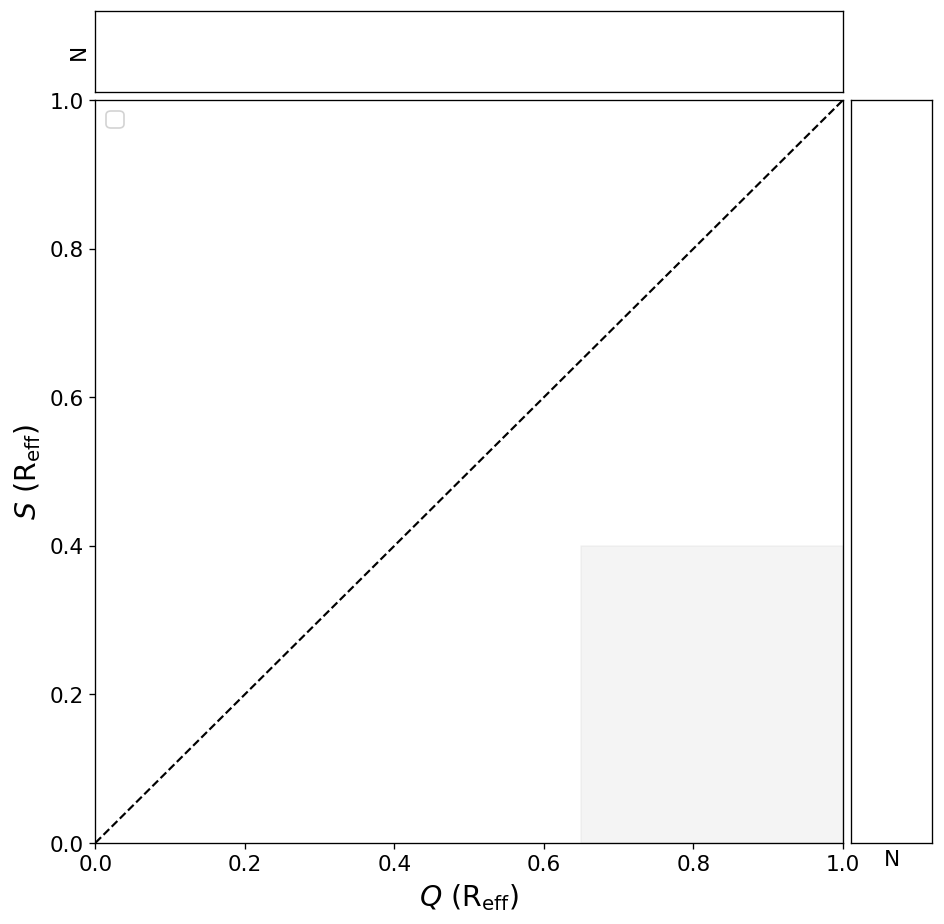

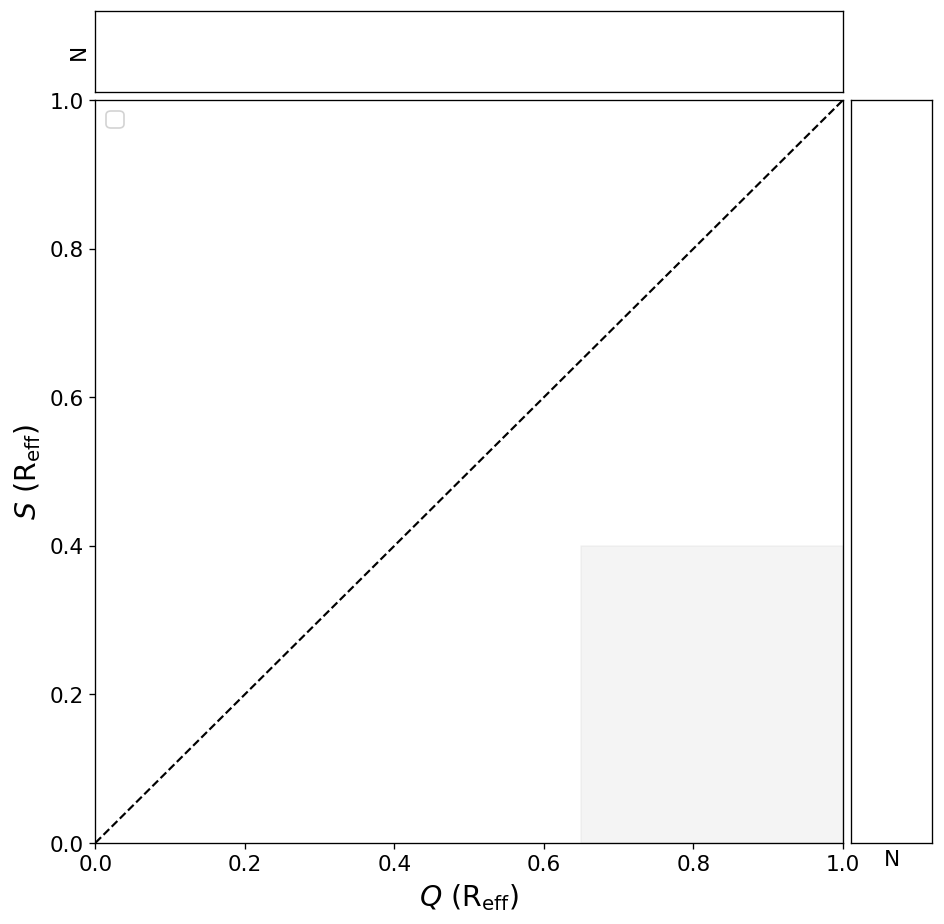

In [9]:

plotter = ShapeColorPlotter(data, sim_markers={'elektra': 'o', 'storm': 's'})

# linked pairs only — clean publication figure
fig, ax = plotter.plot(x_key='ba_s', y_key='ca_s',
                       x_label=r'Q', y_label=r'S',
                       show_unlinked=False,
                       filename='BW-SB.results/sb-bw-3d_linked.png')

# everything including ghost halos — diagnostic / exploratory
fig, ax = plotter.plot(x_key='ba_s', y_key='ca_s',
                       x_label=r'Q', y_label=r'S',
                       show_unlinked=True,
                       filename='BW-SB.results/sb-bw-3d_all.png')

In [ ]:

plotter = ShapeColorPlotter(data, sim_markers={'elektra': 'o', 'storm': 's'})

# linked pairs only — clean publication figure
fig, ax = plotter.plot(x_key='ba_s', y_key='ca_s',
                       x_label=r'Q', y_label=r'S',
                       show_unlinked=False,
                       filename='BW-SB.results/sb-bw-3d_linked.png')

# everything including ghost halos — diagnostic / exploratory
fig, ax = plotter.plot(x_key='ba_s', y_key='ca_s',
                       x_label=r'Q', y_label=r'S',
                       show_unlinked=True,
                       filename='BW-SB.results/sb-bw-3d_all.png')

In [ ]:
pickle_file = 'ellipse_data_SBBW_v_stars_Klein.pickle'
with open(pickle_file, "rb") as f:
    ellipse_dict = pickle.load(f)
    
data = collect_shape_data(
    sb_sims, bw_sims, n_halos=30,
    include_unlinked=True,   # collect failed halos as lone points
)

In [ ]:
pickle_file = 'ellipse_data_SBBW_v_stars_Klein.pickle'
with open(pickle_file, "rb") as f:
    ellipse_dict = pickle.load(f)

In [ ]:
data = collect_shape_data()

In [ ]:
for sim in ellipse_dict:
    print(ellipse_dict[sim])
    #print(ellipse_dict_klein[sim])
    break

In [ ]:
for sim in ellipse_dict:
    #print(ellipse_dict[sim])
    print(ellipse_dict_klein[sim])
    break